<a href="https://colab.research.google.com/github/kellllyyy/mase/blob/lab_kellyngmanyie/tutorial_4_pruning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Tutorial 4: Unstructured Pruning on Bert

Pruning is a technique used to reduce the size and complexity of neural networks by removing unnecessary parameters (weights and connections) or structural components (neurons, filters, or layers). The goal is to create a smaller, more efficient model that maintains most of the original model's performance. The following benefits can be seen from pruning neural networks:

- **Reduce model size**: Deep neural networks often have millions of parameters, leading to large storage requirements.

- **Decrease inference time**: Fewer parameters mean fewer computations, resulting in faster predictions.

- **Improve generalization**: Removing unnecessary connections can help prevent overfitting.

- **Energy efficiency**: Smaller models require less energy to run, which is crucial for edge devices and mobile applications.

Structured pruning removes entire structures (e.g., channels, filters, or layers) from the network, while unstructured pruning removes individual weights or connections from the network, regardless of their location. In this tutorial, we'll build on top of Tutorial 3 by taking the quantized Bert model and running Mase's unstructured pruning pass. After pruning, we'll run further fine tuning iterations to retain sequence classification accuracy in the pruned model.

In [ ]:
%pip uninstall -y optimum transformers datasets evaluate fsspec
%pip install optimum==1.24.0 transformers==4.51 datasets==3.3.2 evaluate==0.4.3 fsspec==2024.12.0

Found existing installation: transformers 4.57.6
Uninstalling transformers-4.57.6:
  Successfully uninstalled transformers-4.57.6
Found existing installation: datasets 4.0.0
Uninstalling datasets-4.0.0:
  Successfully uninstalled datasets-4.0.0
Found existing installation: fsspec 2025.3.0
Uninstalling fsspec-2025.3.0:
  Successfully uninstalled fsspec-2025.3.0
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 433.6/433.6 kB 13.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.4/10.4 MB 103.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 485.4/485.4 kB 50.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.0/84.0 kB 11.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 183.9/183.9 kB 26.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 85.4 MB/s eta 0:00:00
  Attempting uninstall: tokenizers
    Found existing installation: tokenizers 0.22.2
    Uninstalling tokenizers-0.22.2:
      Successfully uninstalled token

In [ ]:
%pip install \
black toml GitPython colorlog \
cocotb==1.9.2 pybind11 \
timm pytorch-nlp sentencepiece einops kornia \
hyperopt@git+https://github.com/hyperopt/hyperopt.git \
optuna stable-baselines3[extra] \
tensorboard tensorboardx wandb lightning pytorch-lightning \
bitarray "bitstring>=4.2" attr-dot-dict emoji \
onnx onnxruntime onnxconverter-common accelerate \
absl-py prettytable pynvml py-cpuinfo psutil cvxpy pydot \
h5py imageio imageio-ffmpeg \
opencv-python matplotlib scikit-learn pandas \
sphinx-rtd-theme "sphinx-needs>=4" \
sphinx-test-reports@git+https://github.com/useblocks/sphinx-test-reports \
sphinxcontrib-plantuml sphinx-glpi-theme \
ghp-import myst_parser myst-nb sphinx-book-theme \
ultralytics==8.3.235

  Cloning https://github.com/hyperopt/hyperopt.git to /tmp/pip-install-93dp2zuw/hyperopt_888f9b930745494bb0dc25a2289dcfb8
  Running command git clone --filter=blob:none --quiet https://github.com/hyperopt/hyperopt.git /tmp/pip-install-93dp2zuw/hyperopt_888f9b930745494bb0dc25a2289dcfb8
  Resolved https://github.com/hyperopt/hyperopt.git to commit 0658f680c84a313eaffe1771a20dfe2ebabd7fd4
  Preparing metadata (setup.py) ... done
  Cloning https://github.com/useblocks/sphinx-test-reports to /tmp/pip-install-93dp2zuw/sphinx-test-reports_791b8c89f7db47e58c05b0fef058e68a
  Running command git clone --filter=blob:none --quiet https://github.com/useblocks/sphinx-test-reports /tmp/pip-install-93dp2zuw/sphinx-test-reports_791b8c89f7db47e58c05b0fef058e68a
  Resolved https://github.com/useblocks/sphinx-test-reports to commit 97df9daec4a50800ecb5cfdcd5a49416840750bf
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done


In [ ]:
import os
os.kill(os.getpid(), 9)

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import sys
sys.path.append('/content/drive/MyDrive/mase/src')
print(f"Added '/content/drive/MyDrive/mase/src' to sys.path")

Added '/content/drive/MyDrive/mase/src' to sys.path


In [ ]:
checkpoint = "prajjwal1/bert-tiny"
tokenizer_checkpoint = "bert-base-uncased"
dataset_name = "imdb"

## Importing the model

If you are starting from scratch, you can create a MaseGraph for Bert by running the following cell.

In [ ]:
from transformers import AutoModelForSequenceClassification

from chop import MaseGraph
import chop.passes as passes

model = AutoModelForSequenceClassification.from_pretrained(checkpoint)
model.config.problem_type = "single_label_classification"

mg = MaseGraph(
    model,
    hf_input_names=[
        "input_ids",
        "attention_mask",
        "labels",
    ],
)

mg, _ = passes.init_metadata_analysis_pass(mg)
mg, _ = passes.add_common_metadata_analysis_pass(mg)

/usr/local/lib/python3.12/dist-packages/torch/cuda/__init__.py:63: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of you

config.json:   0%|          | 0.00/285 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/17.8M [00:00<?, ?B/s]

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at prajjwal1/bert-tiny and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
`past_key_values` were not specified as input names, but model.config.use_cache = True. Setting model.config.use_cache = False.
W0202 16:28:57.352000 2227 torch/fx/_symbolic_trace.py:52] is_fx_tracing will return true for both fx.symbolic_trace and torch.export. Please use is_fx_tracing_symbolic_tracing() for specifically fx.symbolic_trace or torch.compiler.is_compiling() for specifically torch.export/compile.
INFO     Getting dummy input for prajjwal1/bert-tiny.


vocab.txt: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/17.7M [00:00<?, ?B/s]

tensor([[ 101, 9932, 2089, 2202, 2058, 1996, 2088, 2028, 2154,  102],
        [ 101, 2023, 2003, 2339, 2017, 2323, 4553, 4748, 4877,  102]])
tensor([[0, 0, 0, 0, 0, 0, 0, 0, 0, 0]])
tensor([[ 101, 9932, 2089, 2202, 2058, 1996, 2088, 2028, 2154,  102],
        [ 101, 2023, 2003, 2339, 2017, 2323, 4553, 4748, 4877,  102]])
tensor([[1, 1, 1, 1, 1, 1, 1, 1, 1, 1],
        [1, 1, 1, 1, 1, 1, 1, 1, 1, 1]])
tensor([[1, 1, 1, 1, 1, 1, 1, 1, 1, 1],
        [1, 1, 1, 1, 1, 1, 1, 1, 1, 1]])
tensor([[1, 1, 1, 1, 1, 1, 1, 1, 1, 1],
        [1, 1, 1, 1, 1, 1, 1, 1, 1, 1]])
tensor([[[[1, 1, 1, 1, 1, 1, 1, 1, 1, 1]]],


        [[[1, 1, 1, 1, 1, 1, 1, 1, 1, 1]]]])
tensor([[[[1, 1, 1, 1, 1, 1, 1, 1, 1, 1],
          [1, 1, 1, 1, 1, 1, 1, 1, 1, 1],
          [1, 1, 1, 1, 1, 1, 1, 1, 1, 1],
          [1, 1, 1, 1, 1, 1, 1, 1, 1, 1],
          [1, 1, 1, 1, 1, 1, 1, 1, 1, 1],
          [1, 1, 1, 1, 1, 1, 1, 1, 1, 1],
          [1, 1, 1, 1, 1, 1, 1, 1, 1, 1],
          [1, 1, 1, 1, 1, 1, 1, 1, 1, 1],
       

If you have previously ran the tutorial on Quantization-Aware Training (QAT), run the following cell to import the fine tuned checkpoint.

In [ ]:
from pathlib import Path
from chop import MaseGraph

# mg = MaseGraph.from_checkpoint(f"{Path.home()}/tutorial_3_qat")
mg = MaseGraph.from_checkpoint("/content/drive/MyDrive/mase/src/tutorial_3_qat")

## Unstructured Pruning

Before running pruning, let's evaluate the model accuracy on the IMDb dataset. If you're coming from Tutorial, this would be the same as the accuracy after Quantization Aware Training (QAT). If you've just initialized the model, this will likely be a random guess (i.e. around 50%), in which case pruning wouldn't have a significant effect on the accuracy.

In [ ]:
from chop.tools import get_tokenized_dataset, get_trainer

dataset, tokenizer = get_tokenized_dataset(
    dataset=dataset_name,
    checkpoint=tokenizer_checkpoint,
    return_tokenizer=True,
)

trainer = get_trainer(
    model=mg.model,
    tokenized_dataset=dataset,
    tokenizer=tokenizer,
    evaluate_metric="accuracy",
)

# Evaluate accuracy
eval_results = trainer.evaluate()
print(f"Evaluation accuracy: {eval_results['eval_accuracy']}")

INFO     Tokenizing dataset imdb with AutoTokenizer for bert-base-uncased.


README.md: 0.00B [00:00, ?B/s]

plain_text/train-00000-of-00001.parquet:   0%|          | 0.00/21.0M [00:00<?, ?B/s]

plain_text/test-00000-of-00001.parquet:   0%|          | 0.00/20.5M [00:00<?, ?B/s]

plain_text/unsupervised-00000-of-00001.p(…):   0%|          | 0.00/42.0M [00:00<?, ?B/s]

...

Map:   0%|          | 0/25000 [00:00<?, ? examples/s]

Map:   0%|          | 0/25000 [00:00<?, ? examples/s]

Map:   0%|          | 0/50000 [00:00<?, ? examples/s]

/content/drive/MyDrive/mase/src/chop/tools/huggingface.py:157: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


Evaluation accuracy: 0.84048


To run the pruning pass, we pass the following pruning configuration dictionary, which defines the following parameters.

- **Sparsity**: a value between 0 and 1, expressing the proportion of elements in the model that should be pruned (i.e. set to 0).

- **Method**: several pruning methods are supported, including ``Random`` and ``L1-Norm``.

- **Scope**: defines whether to consider each weight/activation tensor individually (``local``) or all tensors in the model (``global``) when obtaining statistics for pruning (e.g. absolute value threshold for pruning)

We'll start by running random pruning with local scope, at a fixed sparsity. This may be suboptimal, but in future tutorials we'll see how to find optimal pruning and quantization configurations for a given model on a specified dataset.

In [ ]:
import chop.passes as passes

pruning_config = {
    "weight": {
        "sparsity": 0.5,
        "method": "l1-norm",
        "scope": "local",
    },
    "activation": {
        "sparsity": 0.5,
        "method": "l1-norm",
        "scope": "local",
    },
}

mg, _ = passes.prune_transform_pass(mg, pass_args=pruning_config)

INFO     Pruning module: bert_encoder_layer_0_attention_self_query
INFO     Pruning module: bert_encoder_layer_0_attention_self_key
INFO     Pruning module: bert_encoder_layer_0_attention_self_value
INFO     Pruning module: bert_encoder_layer_0_attention_output_dense
INFO     Pruning module: bert_encoder_layer_0_intermediate_dense
INFO     Pruning module: bert_encoder_layer_0_output_dense
INFO     Pruning module: bert_encoder_layer_1_attention_self_query
INFO     Pruning module: bert_encoder_layer_1_attention_self_key
INFO     Pruning module: bert_encoder_layer_1_attention_self_value
INFO     Pruning module: bert_encoder_layer_1_attention_output_dense
INFO     Pruning module: bert_encoder_layer_1_intermediate_dense
INFO     Pruning module: bert_encoder_layer_1_output_dense
INFO     Pruning module: bert_pooler_dense
INFO     Pruning module: classifier


Let's evaluate the effect of pruning on accuracy. It's likely to observe drops of around 10% or more.

In [ ]:
trainer = get_trainer(
    model=mg.model,
    tokenized_dataset=dataset,
    tokenizer=tokenizer,
    evaluate_metric="accuracy",
    num_train_epochs=5,
)

# Evaluate accuracy
eval_results = trainer.evaluate()
print(f"Evaluation accuracy: {eval_results['eval_accuracy']}")

/content/drive/MyDrive/mase/src/chop/tools/huggingface.py:157: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


Evaluation accuracy: 0.78744


To overcome the drop in accuracy, we'll run a few finetuning epochs. This allows the model to adapt to the new pruning mask.

In [ ]:
trainer.train()

Step,Training Loss
500,0.460100
1000,0.423700
1500,0.436300
2000,0.418300
2500,0.414500
3000,0.421000
3500,0.426000
4000,0.404000
4500,0.390400
5000,0.392100


TrainOutput(global_step=15625, training_loss=0.39906336889648436, metrics={'train_runtime': 367.2027, 'train_samples_per_second': 340.411, 'train_steps_per_second': 42.551, 'total_flos': 0.0, 'train_loss': 0.39906336889648436, 'epoch': 5.0})

Let's evaluate the model accuracy after finetuning. We should see that the accuracy is reverted back to the original level.

In [ ]:
eval_results = trainer.evaluate()
print(f"Evaluation accuracy: {eval_results['eval_accuracy']}")

Evaluation accuracy: 0.83476


# Implemetation Task
Take your best obtained model from Task 1 and rerun the pruning procedure, this time varying the sparsity from 0.1 to 0.9.

Plot a figure where the x-axis is the sparsity and the y-axis is the highest achieved accuracy on the IMDb dataset, following the procedure in Tutorial 4.

Plot separate curves for Random and L1-Norm methods to evaluate the effect of different pruning strategies.


INFO     Pruning module: bert_encoder_layer_0_attention_self_query
INFO     Pruning module: bert_encoder_layer_0_attention_self_key
INFO     Pruning module: bert_encoder_layer_0_attention_self_value
INFO     Pruning module: bert_encoder_layer_0_attention_output_dense
INFO     Pruning module: bert_encoder_layer_0_intermediate_dense
INFO     Pruning module: bert_encoder_layer_0_output_dense
INFO     Pruning module: bert_encoder_layer_1_attention_self_query
INFO     Pruning module: bert_encoder_layer_1_attention_self_key
INFO     Pruning module: bert_encoder_layer_1_attention_self_value
INFO     Pruning module: bert_encoder_layer_1_attention_output_dense
INFO     Pruning module: bert_encoder_layer_1_intermediate_dense
INFO     Pruning module: bert_encoder_layer_1_output_dense
INFO     Pruning module: bert_pooler_dense
INFO     Pruning module: classifier



Testing pruning method: random


Testing sparsity: 0.1


/content/drive/MyDrive/mase/src/chop/tools/huggingface.py:157: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


Step,Training Loss
500,0.466800
1000,0.429300
1500,0.448500
2000,0.425700
2500,0.421800
3000,0.433700
3500,0.434500
4000,0.420000
4500,0.402500
5000,0.397500


INFO     Pruning module: bert_encoder_layer_0_attention_self_query
INFO     Pruning module: bert_encoder_layer_0_attention_self_key
INFO     Pruning module: bert_encoder_layer_0_attention_self_value
INFO     Pruning module: bert_encoder_layer_0_attention_output_dense
INFO     Pruning module: bert_encoder_layer_0_intermediate_dense
INFO     Pruning module: bert_encoder_layer_0_output_dense
INFO     Pruning module: bert_encoder_layer_1_attention_self_query
INFO     Pruning module: bert_encoder_layer_1_attention_self_key
INFO     Pruning module: bert_encoder_layer_1_attention_self_value
INFO     Pruning module: bert_encoder_layer_1_attention_output_dense
INFO     Pruning module: bert_encoder_layer_1_intermediate_dense
INFO     Pruning module: bert_encoder_layer_1_output_dense
INFO     Pruning module: bert_pooler_dense
INFO     Pruning module: classifier


...

INFO     Pruning module: bert_encoder_layer_0_attention_self_query
INFO     Pruning module: bert_encoder_layer_0_attention_self_key
INFO     Pruning module: bert_encoder_layer_0_attention_self_value
INFO     Pruning module: bert_encoder_layer_0_attention_output_dense
INFO     Pruning module: bert_encoder_layer_0_intermediate_dense
INFO     Pruning module: bert_encoder_layer_0_output_dense
INFO     Pruning module: bert_encoder_layer_1_attention_self_query
INFO     Pruning module: bert_encoder_layer_1_attention_self_key
INFO     Pruning module: bert_encoder_layer_1_attention_self_value
INFO     Pruning module: bert_encoder_layer_1_attention_output_dense
INFO     Pruning module: bert_encoder_layer_1_intermediate_dense
INFO     Pruning module: bert_encoder_layer_1_output_dense
INFO     Pruning module: bert_pooler_dense
INFO     Pruning module: classifier


Sparsity: 0.7, Method: l1-norm, Accuracy: 0.8012

Testing sparsity: 0.9


/content/drive/MyDrive/mase/src/chop/tools/huggingface.py:157: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


Step,Training Loss
500,0.692900
1000,0.692000
1500,0.692100
2000,0.692100
2500,0.691600
3000,0.691300
3500,0.691400
4000,0.691200
4500,0.690300
5000,0.690000


Sparsity: 0.9, Method: l1-norm, Accuracy: 0.5539


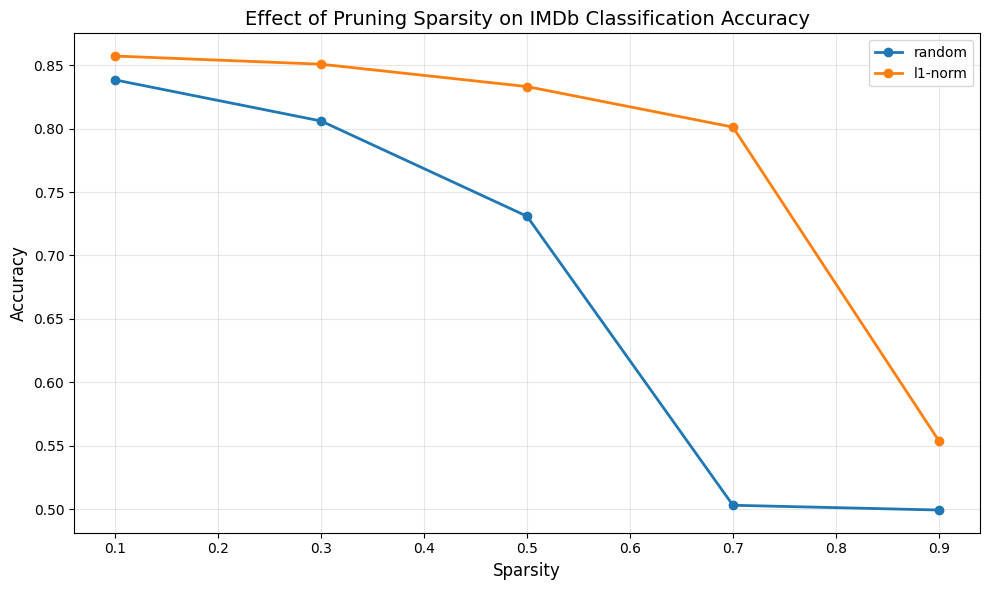


Summary of Results

RANDOM:
  Sparsity 0.1: 0.8384
  Sparsity 0.3: 0.8060
  Sparsity 0.5: 0.7309
  Sparsity 0.7: 0.5030
  Sparsity 0.9: 0.4992

L1-NORM:
  Sparsity 0.1: 0.8573
  Sparsity 0.3: 0.8508
  Sparsity 0.5: 0.8332
  Sparsity 0.7: 0.8012
  Sparsity 0.9: 0.5539


In [ ]:
import numpy as np

import matplotlib.pyplot as plt

# Define sparsity levels to test
sparsity_levels = np.arange(0.1, 1.0, 0.2)
pruning_methods = ["random", "l1-norm"]

# Dictionary to store results
results = {method: [] for method in pruning_methods}

# Loop through each pruning method
for method in pruning_methods:
    print(f"\n{'='*50}")
    print(f"Testing pruning method: {method}")
    print(f"{'='*50}\n")

    # Loop through each sparsity level
    for sparsity in sparsity_levels:
        print(f"\nTesting sparsity: {sparsity:.1f}")

        # Reload the model from checkpoint (best model from Task 1)
        # mg = MaseGraph.from_checkpoint(f"{Path.home()}/tutorial_3_qat")
        mg = MaseGraph.from_checkpoint("/content/drive/MyDrive/mase/src/tutorial_3_qat")

        # Define pruning configuration
        pruning_config = {
            "weight": {
                "sparsity": sparsity,
                "method": method,
                "scope": "local",
            },
            "activation": {
                "sparsity": sparsity,
                "method": method,
                "scope": "local",
            },
        }

        # Apply pruning
        mg, _ = passes.prune_transform_pass(mg, pass_args=pruning_config)

        # Create trainer
        trainer = get_trainer(
            model=mg.model,
            tokenized_dataset=dataset,
            tokenizer=tokenizer,
            evaluate_metric="accuracy",
            num_train_epochs=5,
        )

        # Fine-tune the pruned model
        trainer.train()

        # Evaluate accuracy
        eval_results = trainer.evaluate()
        accuracy = eval_results['eval_accuracy']
        results[method].append(accuracy)

        print(f"Sparsity: {sparsity:.1f}, Method: {method}, Accuracy: {accuracy:.4f}")

# Plot the results
plt.figure(figsize=(10, 6))
for method in pruning_methods:
    plt.plot(sparsity_levels, results[method], marker='o', label=method, linewidth=2)

plt.xlabel('Sparsity', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.title('Effect of Pruning Sparsity on IMDb Classification Accuracy', fontsize=14)
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
# Save to home directory
# plt.savefig(f"{Path.home()}/pruning_sparsity_comparison.png", dpi=300, bbox_inches='tight')
plt.savefig(f"/content/drive/MyDrive/mase/src/pruning_sparsity_comparison.png", dpi=300, bbox_inches='tight')
plt.show()


# Print summary
print("\n" + "="*50)
print("Summary of Results")
print("="*50)
for method in pruning_methods:
    print(f"\n{method.upper()}:")
    for i, sparsity in enumerate(sparsity_levels):
        print(f"  Sparsity {sparsity:.1f}: {results[method][i]:.4f}")